# Introduction to Time Series Forecasting with Statistical Models

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

import warnings
warnings.filterwarnings("ignore")

Initial setup

In [3]:
df = pd.read_csv("daily_sales_french_bakery.csv", parse_dates=["ds"])
df = df.groupby('unique_id').filter(lambda x: len(x) >= 28)
df = df.drop(["unit_price"], axis=1)
df.head()

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


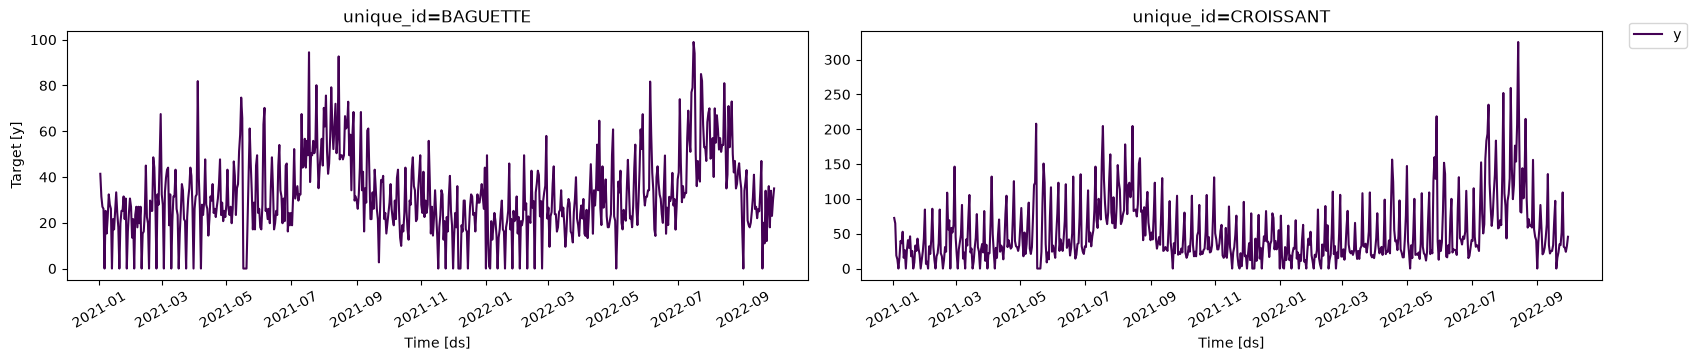

In [4]:
plot_series(df=df, ids=["BAGUETTE", "CROISSANT"], palette="viridis")

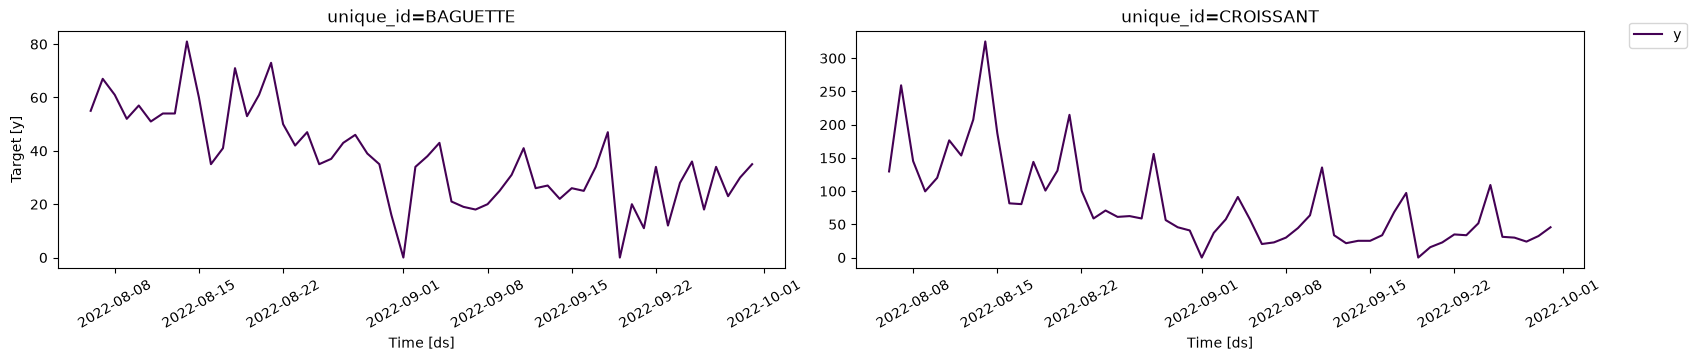

In [5]:
plot_series(df=df, ids=["BAGUETTE", "CROISSANT"], max_insample_length=56, palette="viridis")

# Baseline Models

In [6]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
# Naive = data terakhir
# Historic average = rata2 dari awal sampai sekarang
# Window average = rata2 dari awal sampai akhir rentang waktu tertentu
# seasonal naive = pola musiman terakhir

In [7]:
horizon = 7
# karena datanya harian

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]

# objek untuk pelatihan, inferensi, dan validasi
# D = daily (harian)
sf = StatsForecast(models=models, freq="D")
sf.fit(df=df)
preds = sf.predict(h=horizon)

In [8]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0


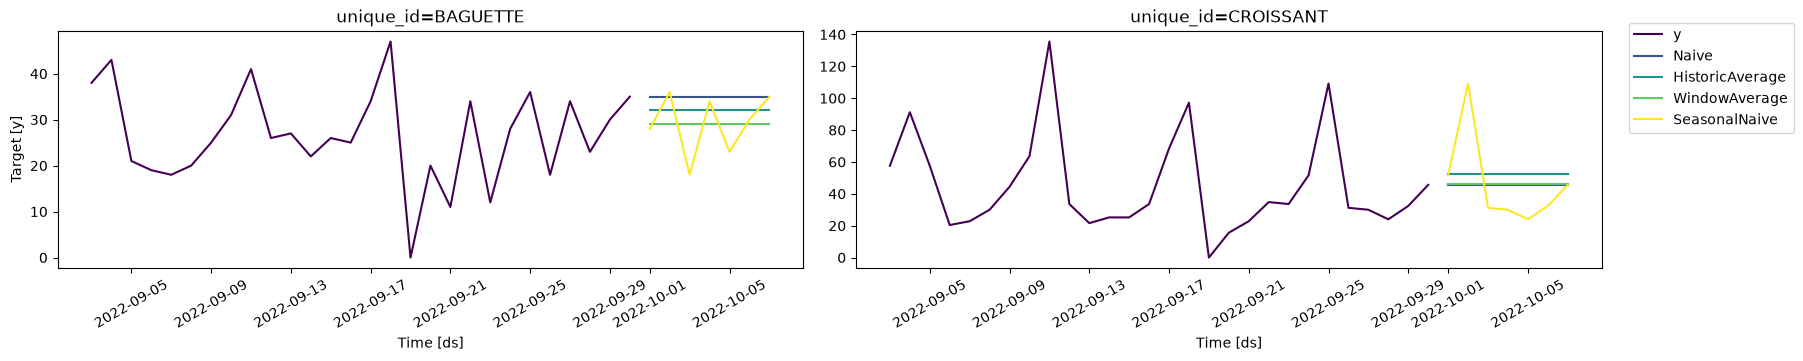

In [9]:
plot_series(
    df=df,
    forecasts_df=preds,
    ids=["BAGUETTE", "CROISSANT"],
    max_insample_length=28,
    palette="viridis"
)

# Evaluating Baseline Models

In [10]:
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)

In [11]:
sf.fit(df=train)
preds = sf.predict(h=horizon)
eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

In [12]:
evaluation = evaluate(
    eval_df,
    metrics=[mae],
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.469388,4.285714
1,BAGUETTE,mae,17.142857,5.455193,7.877551,12.571429
2,BAGUETTE APERO,mae,0.000000,0.537572,0.642857,0.642857
3,BAGUETTE GRAINE,mae,9.800000,4.612271,2.942857,0.200000
4,BANETTE,mae,1.314286,5.421984,6.008163,7.885714


In [13]:
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636


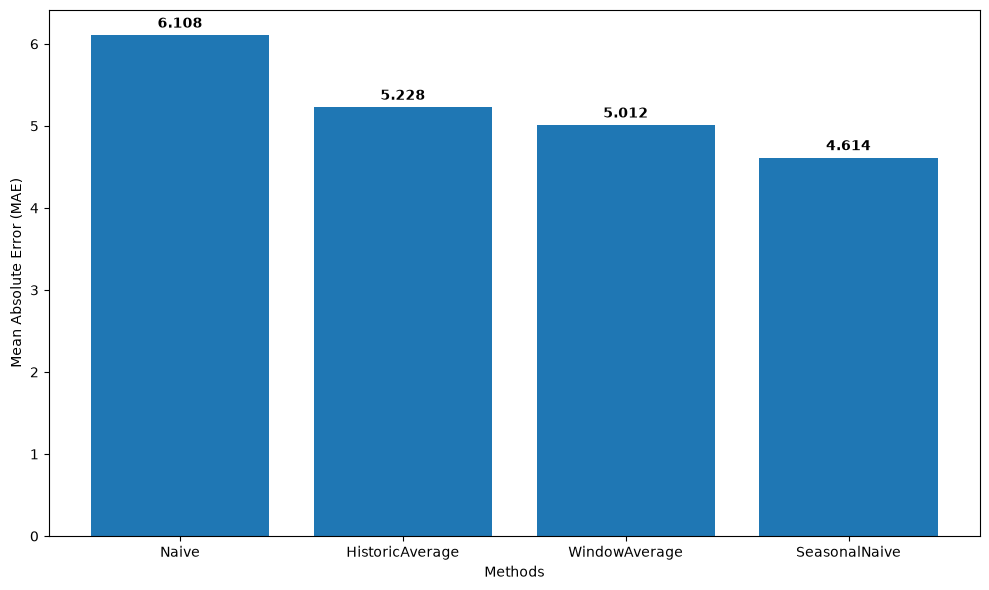

In [14]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
    f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean Absolute Error (MAE)')
plt.tight_layout()

plt.show()

In [15]:
# print(type(values))
print(values)

[np.float64(6.107556080283353), np.float64(5.22843851951185), np.float64(5.011663012312363), np.float64(4.613636363636363)]


Performa model-model dasar ini akan jadi pembanding untuk performa model yang kita buat sendiri

# AutoARIMA

Model statistik:
- ARIMA (AutoRegressive Integrated Moving Average)
- Exponential smoothing
- Theta model (decomposition approach)
- MSTL, BATS, TBATS (multiple seasonal periods)
- Croston, IMAPA, TSB (intermittent series)

In [16]:
from statsforecast.models import AutoARIMA
# ARIMA punya banyak parameter
# AutoARIMA mencari kombinasi parameter paling optimal
# jadi cukup atur m saja

In [17]:
unique_ids = ["BAGUETTE", "CROISSANT"]

small_train = train[train['unique_id'].isin(unique_ids)]
small_test = test[test['unique_id'].isin(unique_ids)]

models = [
    AutoARIMA(seasonal=False, alias='ARIMA'),
    AutoARIMA(season_length=7, alias='SARIMA'),
]

sf = StatsForecast(models=models, freq='D')
sf.fit(df=small_train)

arima_preds = sf.predict(h=horizon)

arima_eval_df = pd.merge(arima_preds, eval_df, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(
    arima_eval_df,
    metrics=[mae]
)
arima_eval

arima_mape = evaluate(
    arima_eval_df,
    metrics=[mape]
)

In [18]:
arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,11.959274,8.904113,17.314286,14.037063,13.061224,12.714286


In [19]:
arima_mape = arima_mape.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_mape

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mape,0.266715,0.234648,0.420868,0.401919,0.298667,0.39618


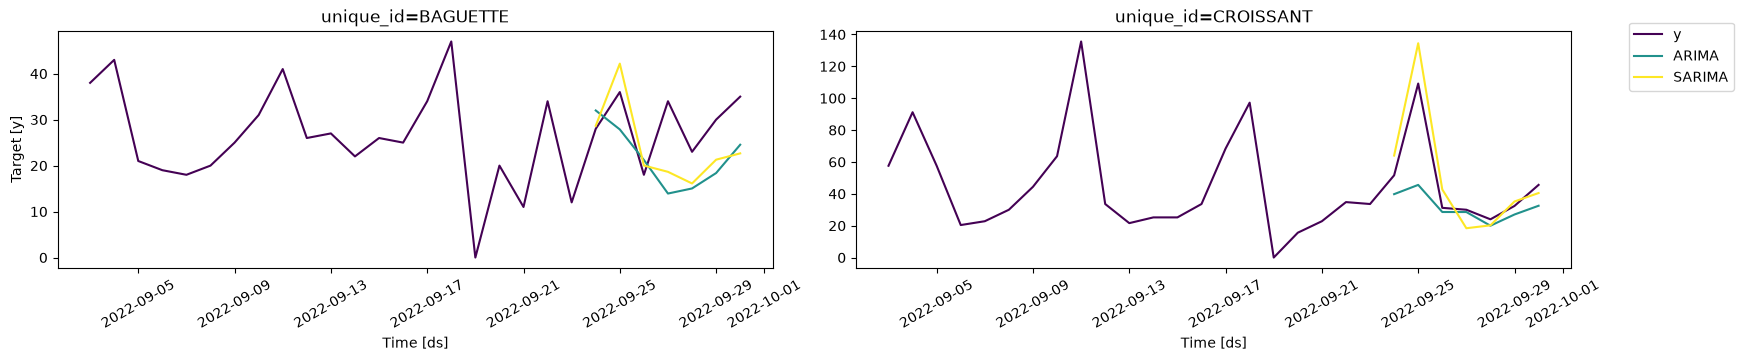

In [20]:
plot_series(
    df=df,
    forecasts_df=arima_preds,
    ids=["BAGUETTE", "CROISSANT"],
    max_insample_length=28,
    palette="viridis"
)

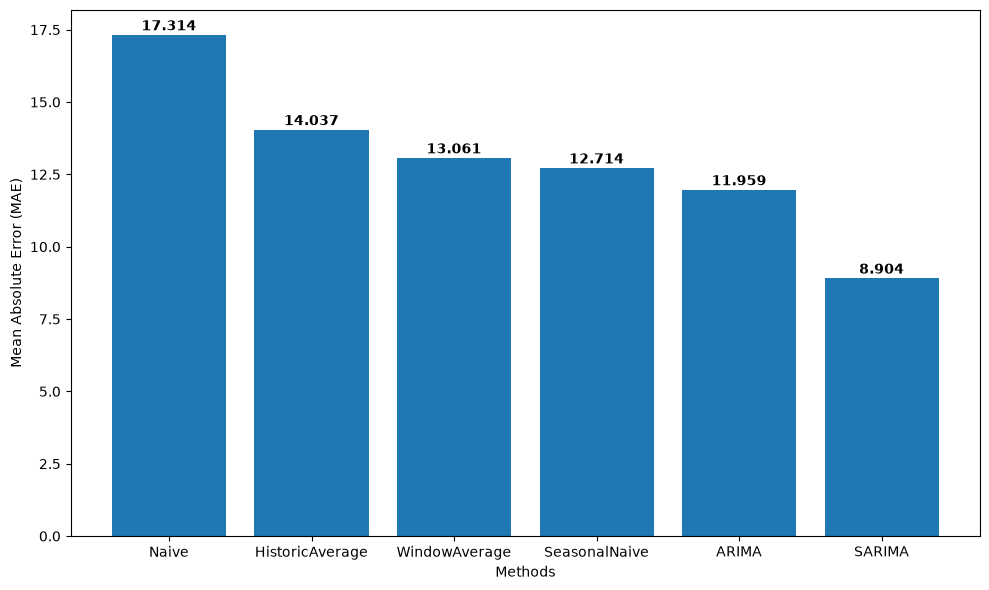

In [21]:
methods = arima_eval.columns[1:].tolist()
values = arima_eval.iloc[0, 1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean Absolute Error (MAE)')
plt.tight_layout()

plt.show()

# Cross-validation

In [23]:
small_df = df[df['unique_id'].isin(unique_ids)]

models = [
    SeasonalNaive(season_length=7),
    AutoARIMA(seasonal=False, alias='ARIMA'),
    AutoARIMA(season_length=7, alias='SARIMA')
]

sf = StatsForecast(models=models, freq='D')
cv_df = sf.cross_validation(
    h=horizon,
    df=small_df,
    n_windows=8,
    step_size=horizon,
    refit=True,
)
# refit = optimisasi setiap kali jendela diperbesar
# pakai kalau model kita akan dihitung ulang setiap kali dapat data baru
# kalau pelatihan tidak sering saat deployment, tidak perlu

cv_df.head()

,unique_id,ds,cutoff,y,SeasonalNaive,ARIMA,SARIMA
0,BAGUETTE,2022-08-06,2022-08-05,55.0,68.0,71.355196,71.584713
1,BAGUETTE,2022-08-07,2022-08-05,67.0,70.0,70.337980,78.458883
2,BAGUETTE,2022-08-08,2022-08-05,61.0,48.0,61.195004,57.001732
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.0,52.649013,49.401144
4,BAGUETTE,2022-08-10,2022-08-05,57.0,57.0,47.785876,49.725278


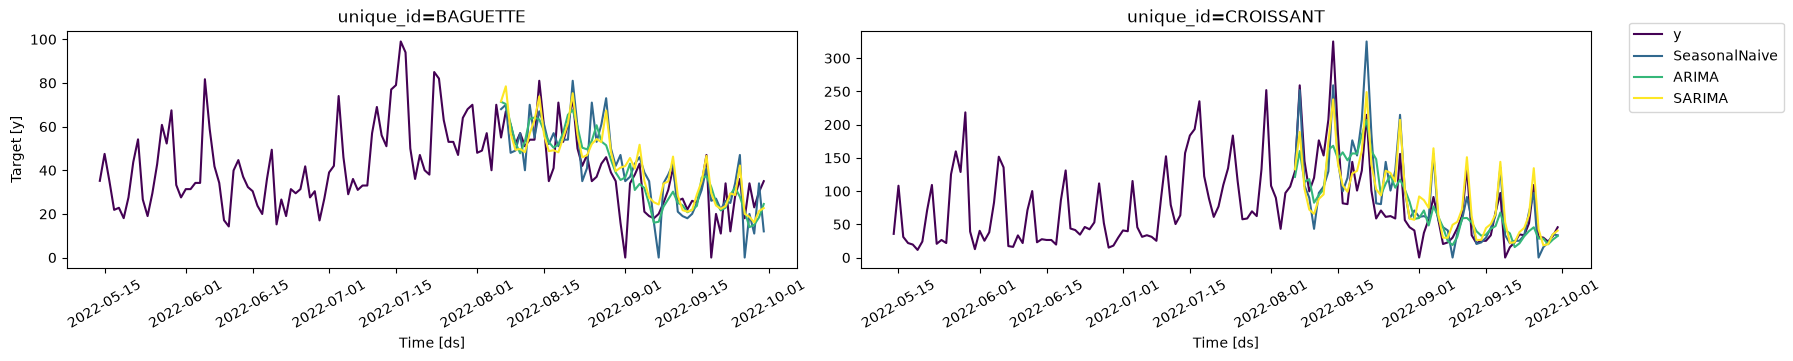

In [26]:
plot_series(
    df=small_df,
    forecasts_df=cv_df.drop(['y', 'cutoff'], axis=1),
    ids=["BAGUETTE", "CROISSANT"],
    max_insample_length = 140,
    palette="viridis",
)

In [29]:
cv_eval = evaluate(
    cv_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)

cv_eval = cv_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval

,metric,SeasonalNaive,ARIMA,SARIMA
0,mae,21.117857,21.17093,19.281296


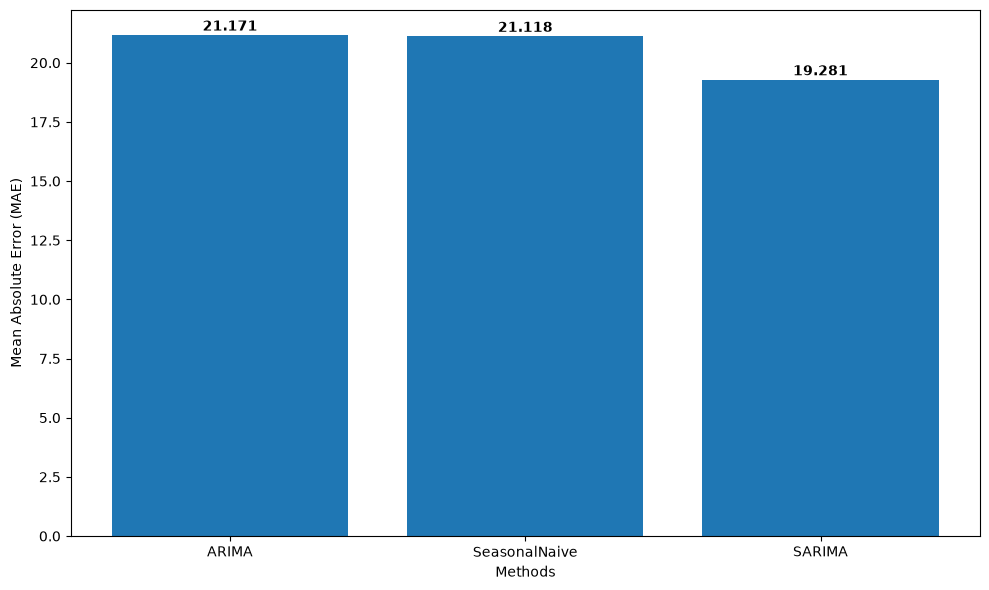

In [30]:
methods = cv_eval.columns[1:].tolist()
values = cv_eval.iloc[0, 1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean Absolute Error (MAE)')
plt.tight_layout()

plt.show()

# Forecasting with Exogenous Features